# Машинное обучение, РЭШ

## Практическое задание 3. Классификация. 

### Общая информация
Дата выдачи: 29.11.2020

Мягкий дедлайн: 23:59MSK 05.11.2020 (за каждый день просрочки снимается 1 балл)

Жесткий дедлайн: 23:59MSK 07.11.2020

### О задании

В этом задании вы:
- ознакомитесь с тем, что происходит "внутри" метода опорных векторов и логистической регрессии
- познакомитесь с калибровкой вероятности
- изучите методы трансформации переменных и методы отбора признаков
- попробуете оценить экономический эффект модели


### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.


### Формат сдачи
Для сдачи задания загрузите *.ipynb файл на my.nes.
Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: 

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

In [2]:
def pprint(*args, **kwargs):
    print(">>", *args, **kwargs)

# Часть 0. SVM, LR и калибровка вероятностей. 

Сгенерируем синтетические данные.

In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=10000, n_features=10, n_informative=5, n_redundant=5,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [4]:
pd.DataFrame(y_train, columns=["y"]).value_counts(normalize=True)

y
0    0.503143
1    0.496857
Name: proportion, dtype: float64

__Задание 1.__ Обучение и применение метода опорных векторов и логистической регрессии.

__(1 балл)__

Обучите метод опорных векторов. На занятиях мы проходили линейный вариант без ядрового перехода, что соответствует линейному ядру (`LinearSVC` или же `SVC(kernel='linear')` в `sklearn.svm`). Подберите параметр регуляризации `C` (можете воспользоваться кросс-валидацией или отделить валидационную выборку от обучающей).

In [12]:
#your code here
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC, LinearSVC


svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="linear")),
    # ("svc", LinearSVC()),
])

gscv_svm = GridSearchCV(svm_pipe,
                        param_grid={"svc__C": np.logspace(-6, 1, num=10)},
                        scoring="roc_auc", cv=5, n_jobs=-1)
gscv_svm.fit(X_train, y_train)
pprint(f"best score is {gscv_svm.best_score_:.5f} for parameter C : {gscv_svm.best_params_}")

ValueError: 
All the 50 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/saprikins/Documents/PycharmProjects/ml_course_hws/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/saprikins/Documents/PycharmProjects/ml_course_hws/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/saprikins/Documents/PycharmProjects/ml_course_hws/.venv/lib/python3.12/site-packages/sklearn/pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_param

На тестовой части посчитайте AUC-ROC, AUC-PR с точностью до 5 знаков. Постройте ROC и PR кривые, сравните их с ответами случайного классификатора. Заметим, что с помощью `sklearn` можно посчитать обе метрики двумя разными способами - в чем их различия? Сравните результаты.

**Answer**: the difference between `roc_auc_score`/`average_precision_score` and `auc` is the way the area under the curve is calculated. While the former use the Riemann sum, the latter applies the trapezoidal method. In case of ROC AUC, it won't affect the score.

In [ ]:
#your code here
from sklearn.metrics import roc_auc_score, average_precision_score, auc, roc_curve, precision_recall_curve

# for svm, score (scalar product of weight and objects) is a signed distance to the hyperplane
y_test_score = gscv_svm.decision_function(X_test)
fpr, tpr, roc_p_thresholds = roc_curve(y_test, y_test_score)
precision, recall, pr_p_thresholds = precision_recall_curve(y_test, y_test_score)

pprint(f"test auc-roc: {roc_auc_score(y_test, y_test_score):.5f} using roc_auc_score")
pprint(f"test auc-roc: {auc(fpr, tpr):.5f} using auc")
pprint(f"random classifier auc-roc: {0.5}\n")
pprint(f"test auc-pr: {average_precision_score(y_test, y_test_score):.5f} using average_precision_score")
pprint(f"test auc-pr: {auc(recall, precision):.5f} using auc")
pprint(f"random classifier auc-pr: {np.mean(y_test):.5f}")

In [ ]:
# try seaborn for the sake of variety
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
sns.lineplot(x=fpr, y=tpr, ax=axes[0], label="ROC Curve from SVM", color="blue")
sns.lineplot(x=[0, 1], y=[0, 1], ax=axes[0], label="Baseline ROC Curve", linestyle="--", color="red")
axes[0].set_title("ROC curve")
axes[0].set(xlabel="FPR", ylabel="TPR")

sns.lineplot(x=recall, y=precision, ax=axes[1], label="PR Curve from SVM", color="blue")
sns.lineplot(x=[0, 1], y=[np.mean(y_test), np.mean(y_test)], ax=axes[1], label="Baseline PR Curve", linestyle="--", color="red")
axes[1].set_title("SVM PR Curve")
axes[1].set(xlabel="Recall", ylabel="Precision")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.tight_layout()
plt.show()

А теперь проделайте все то же самое для логистической регрессии (LR) — обучение, подбор параметра регуляризации (используйте L2-регуляризацию), вычисление всех метрик и построение кривых. Сравните результаты LR и SVM с точки зрения всех вычисленных критериев качества, объясните различия (если они есть).

In [ ]:
#your code here
from sklearn.linear_model import LogisticRegression
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("log_regression", LogisticRegression(l1_ratio=0)),
])

gscv_lr = GridSearchCV(lr_pipe,
                       param_grid={"log_regression__C": np.logspace(-6, 1, num=10)},
                       scoring="roc_auc", cv=5, n_jobs=-1)
gscv_lr.fit(X_train, y_train)
pprint(f"best score is {gscv_lr.best_score_:.5f} for parameter C : {gscv_lr.best_params_}")

In [ ]:
# for lr, the score (scalar product of weight and objects) represents log odds of the positive class
y_test_score = gscv_lr.decision_function(X_test)
fpr, tpr, roc_p_thresholds = roc_curve(y_test, y_test_score)
precision, recall, pr_p_thresholds = precision_recall_curve(y_test, y_test_score)

pprint(f"test auc-roc: {roc_auc_score(y_test, y_test_score):.5f} using roc_auc_score")
pprint(f"test auc-roc: {auc(fpr, tpr):.5f} using auc")
pprint(f"random classifier auc-roc: {0.5}\n")
pprint(f"test auc-pr: {average_precision_score(y_test, y_test_score):.5f} using average_precision_score")
pprint(f"test auc-pr: {auc(recall, precision):.5f} using auc")
pprint(f"random classifier auc-pr: {np.mean(y_test):.5f}")

In [ ]:
# try seaborn for the sake of variety
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))
sns.lineplot(x=fpr, y=tpr, ax=axes[0], label="ROC Curve from SVM", color="blue")
sns.lineplot(x=[0, 1], y=[0, 1], ax=axes[0], label="Baseline ROC Curve", linestyle="--", color="red")
axes[0].set_title("ROC curve")
axes[0].set(xlabel="FPR", ylabel="TPR")

sns.lineplot(x=recall, y=precision, ax=axes[1], label="PR Curve from SVM", color="blue")
sns.lineplot(x=[0, 1], y=[np.mean(y_test), np.mean(y_test)], ax=axes[1], label="Baseline PR Curve", linestyle="--", color="red")
axes[1].set_title("SVM PR Curve")
axes[1].set(xlabel="Recall", ylabel="Precision")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.tight_layout()
plt.show()

Сгенерируйте синтетический набор данных с помощью функции `make_classification(..)` с числом признаков, равным 2 для выполнения следующего (**и только следующего задания**) задания.

Логистическая регрессия приближает в каждой точке пространства объектов правдоподобие положительных ответов $p(y=+1|x)$. Попробуйте нарисовать это распределение на плоскости, не забудьте отметить на ней все объекты. Вам может помочь функция `plt.pcolor`.

In [ ]:
#your code here
X, y = make_classification(n_samples=10000, n_features=2, n_informative=2, n_redundant=0, random_state=42)
lr_model = LogisticRegression(C=gscv_lr.best_params_["log_regression__C"])
lr_model.fit(X, y);

In [ ]:
# we want a dense grid to build probabilities on dots
n_dots = int(10e2)
grid_x, grid_y = np.meshgrid(np.linspace(-5, 5, n_dots), np.linspace(-6, 5, n_dots))
grid_probs = lr_model.predict_proba(np.column_stack((grid_x.ravel(), grid_y.ravel())))[:, 1]

In [ ]:
fig = plt.figure(figsize=(20, 5))
pc = plt.pcolormesh(grid_x, grid_y, grid_probs.reshape(n_dots, n_dots), cmap="spring", shading="auto")
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y, palette=["darkgreen", "darkred"])
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="upper right", title="Class")
plt.colorbar(pc, label="Probability of class")
plt.tight_layout()
plt.show()

Let's explicitly derive the equation of the division line
$$
p(y=+1|x) = \sigma(<w,x> + w_0) = \dfrac{1}{1 + e^{-(<w,x> + w_0)}} \quad \Rightarrow \quad <w,x> + w_0 = \log\dfrac{p(y=+1|x)}{p(y=-1|x)}
$$
As far as $\sigma(0)=0.5$ (we haven't modified the threshold), we can derive
$$
<w,x> + w_0 = 0 \quad \Rightarrow \quad w_1 x_1 + w_2 x_2 + w_0 = 0 \quad \Rightarrow \quad x_1 = -\dfrac{w_0}{w_1} - \dfrac{w_2}{w_1}x_2,
$$
where weight and the intercept are shown below

In [ ]:
pprint("weights w_1 and w_2 are:", lr_model.coef_)
pprint("intercept w_0 is", lr_model.intercept_)

Also, for the SVM approach let's depict the support vector

In [ ]:
X, y = make_classification(n_samples=10000, n_features=2, n_informative=2, n_redundant=0, random_state=42)
svm_model = SVC(kernel="linear", C=gscv_svm.best_params_["svc__C"], probability=True)
svm_model.fit(X, y)

In [ ]:
# we want a dense grid to build probabilities on dots
n_dots = int(10e2)
grid_x, grid_y = np.meshgrid(np.linspace(-5, 5, n_dots), np.linspace(-6, 5, n_dots))
grid_probs = svm_model.predict_proba(np.column_stack((grid_x.ravel(), grid_y.ravel())))[:,1]

In [ ]:
fig = plt.figure(figsize=(20, 5))
pc = plt.pcolormesh(grid_x, grid_y, grid_probs.reshape(n_dots, n_dots), cmap="spring", shading="auto")
sns.scatterplot(x=X[:,0], y=X[:,1],
                hue=pd.Series(y).map({0: "Class 0", 1: "Class 1"}), palette=["blue", "red"], alpha=0.8)
sns.scatterplot(x=svm_model.support_vectors_[:, 0], y=svm_model.support_vectors_[:, 1],
                hue=pd.Series(y[svm_model.support_]).map({0: "Class 0 support vector", 1: "Class 1 support vector"}), palette=["darkblue", "darkred"], alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="upper right", title="Class")
plt.colorbar(pc, label="Probability of class")
plt.tight_layout()
plt.show()

Again, the equation of separating hyperplane here is:
$$
<w,x> + w_0 = 0 \quad \Rightarrow \quad w_1 x_1 + w_2 x_2 + w_0 = 0 \quad \Rightarrow \quad x_1 = -\dfrac{w_0}{w_1} - \dfrac{w_2}{w_1}x_2,
$$
with the coefficients and an intercept

In [ ]:
pprint("weights w_1 and w_2 are:", svm_model.coef_)
pprint("intercept w_0 is", svm_model.intercept_)

__Задание 2.__ Калибровка вероятностей.

__(1 балл)__

Перейдём к оценке качества выдаваемых алгоритмами вероятностей. Начнём с калибровочных кривых. 

Допустим, алгоритм возвращает некоторые числа от нуля до единицы. Хорошо ли они оценивают вероятность? Для этого разобьем отрезок $[0, 1]$ на несколько маленьких отрезков одинаковой длины. Рассмотрим $i$-й отрезок с границами $[a_i, b_i]$ и предсказания $p_1, p_2, \dots, p_k$, которые попали в него. Пусть им соответствуют истинные ответы $y_1, y_2, \dots, y_k$. Если алгоритм выдает корректные вероятности, то среди этих истинных ответов должно быть примерно $(a_i + b_i) / 2$ единиц. Иными словами, если нарисовать кривую, у которой по оси X отложены центры отрезков, а по оси Y — доли единичных ответов этих в отрезках, то она должна оказаться диагональной. Ниже приведена функция, которая должна рисовать такие кривые. В ней допущено две ошибки — найдите и исправьте их.

In [ ]:
def plot_calibration_curve(y_test, preds, ax):
    bin_middle_points = []
    bin_real_ratios = []
    n_bins = 10
    for i in range(n_bins):
        l = 1.0 / n_bins * i
        r = 1.0 / n_bins * (i + 1)
        bin_middle_points.append((r + l) / 2)
        bin_real_ratios.append(np.mean(y_test[(preds >= l) & (preds < r)] == 1))
    sns.lineplot(x=bin_middle_points, y=bin_real_ratios, label="Predicted probabilities", ax=ax)
    sns.lineplot(x=bin_middle_points, y=bin_middle_points, label="Probabilities of perfect calibration", linestyle="--", ax=ax)
    ax.set(xlabel="Midpoints of bins", ylabel="Fraction of positive class instances")

Сгенерируйте синтетический датасет аналогично использованному в самом первом задании — он будет выступать в качестве тестовой выборки. Постройте калибровочные кривые на тестовой части для логистической регрессии и метода опорных векторов (не забудьте перевести его предсказания в $[0;1]$). Изучите распределение ответов классификаторов (постройте гистограммы с помощью `plt.hist`). Чем они различаются? Чем вы можете объяснить это?

In [ ]:
#your code here
X, y = make_classification(n_samples=10000, n_features=10, n_informative=5, n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
plot_calibration_curve(y_test=y_test, preds=gscv_lr.predict_proba(X_test)[:,1], ax=axes[0])

# here, let's ease the penalty for misclassification
svm_temp = SVC(kernel="linear",
               C=1e-10
               # C=gscv_svm.best_params_["svc__C"]
               )
svm_temp.fit(X_train, y_train)
svm_distances = svm_temp.decision_function(X_test)
svm_distances_normalized = (svm_distances - svm_distances.min())/(svm_distances.max() - svm_distances.min())
plot_calibration_curve(y_test=y_test, preds=svm_distances_normalized, ax=axes[1])

In [ ]:
# let's also try built-in function
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.preprocessing import MinMaxScaler
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
prob_true_lr, prob_pred_lr =  calibration_curve(y_test, gscv_lr.predict_proba(X_test)[:,1], n_bins=20)
sns.lineplot(x=prob_pred_lr, y=prob_true_lr, label="Predicted probabilities", ax=axes[0])
sns.lineplot(x=[0, 1], y=[0, 1], label="Probabilities of perfect calibration", linestyle="--", ax=axes[0])

prob_true_svm, prob_pred_svm = calibration_curve(y_test,
                                                 MinMaxScaler().fit_transform(X=svm_temp.decision_function(X_test)[:, np.newaxis])[:, 0],
                                                 n_bins=20)
sns.lineplot(x=prob_pred_svm, y=prob_true_svm, label="Predicted probabilities", ax=axes[1])
sns.lineplot(x=[0, 1], y=[0, 1], label="Probabilities of perfect calibration", linestyle="--", ax=axes[1])
plt.show()

It demonstrates the difference in the meaning of returned scores by logistic regression and SVM:
- The logistic regression by the constructed loss function (a sigmoid function of scalar product applied to the cross-binary entropy loss) returns log-odds using `decision_function`, and probabilities of belonging to the positive class using `predict_proba` (which is calculated as a sigmoid function to log-odds). That explains the close shape of the calibration curve to one of the perfectly calibrated model. And also, a near-universal distribution of predicted probabilities.
- Meanwhile, SVM via `decision_function` returns the signed distance of objects to a separating hyperplane, which can not be interpreted as probability of belonging to the positive class. In others words, probabilities of the positive class is not natively returned by SVM, unless calibration, as the Platt scaling, is used (that is what happens when `probability=True` is set inside `SVC`, which allows to call `predict_proba`). For that reason we transform signed distance using the min-max scaling to be in the range [0, 1], serving as a proxy of probability. Still, such proxy shows on the calibration curve that objects far from the hyperplane get either under- or over-estimated figures. A spike around 0.5 reflects that majority of observations are set close to the hyperplane.

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 5))

ax[0].hist(gscv_lr.predict_proba(X_test)[:,1], bins=10, color="blue")
ax[0].set_title("Answers for Logistic Regression")
ax[0].set(xlabel="Predicted Probabilities", ylabel="Frequency")

ax[1].hist(svm_distances_normalized, bins=10, color="red")
ax[1].set_title("Answers for SVC")
ax[1].set(xlabel="Predicted Probabilities", ylabel="Frequency")

plt.show()

Воспользуйтесь `CalibratedClassifierCV` из `sklearn` для калибровки вероятностей метода опорных векторов на обучении и постройте с его помощью предсказания для тестовой выборки. Нарисуйте для них калибровочную кривую. Улучшилась ли она?

In [ ]:
#your code her
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
from sklearn.calibration import CalibratedClassifierCV
svm_temp = SVC(kernel="linear",
               C=1e-10
               # C=gscv_svm.best_params_["svc__C"]
               )
calibrator = CalibratedClassifierCV(svm_temp)
calibrator.fit(X_train, y_train)

plot_calibration_curve(y_test=y_test, preds=gscv_lr.predict_proba(X_test)[:, 1], ax=axes[0])
plot_calibration_curve(y_test=y_test, preds=calibrator.predict_proba(X_test)[:, 1], ax=axes[1])

In [ ]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(20, 5))

ax[0].hist(gscv_lr.predict_proba(X_test)[:,1], bins=10, color="blue")
ax[0].set_title("Answers for Logistic Regression")
ax[0].set(xlabel="Predicted Probabilities", ylabel="Frequency")

ax[1].hist(calibrator.predict_proba(X_test)[:, 1], bins=10, color="red")
ax[1].set_title("Answers for SVC")
ax[1].set(xlabel="Predicted Probabilities", ylabel="Frequency")

plt.show()

# Часть 1. Работа с переменными.

В этой части мы научимся обрабатывать категориальные переменные, так как закодировать их в виде чисел недостаточно (это задаёт некоторый порядок, которого на категориальных переменных может и не быть). Существует два основных способа обработки категориальных значений:
- One-hot-кодирование
- Счётчики (CTR, mean-target кодирование, ...) — каждый категориальный признак заменяется на среднее значение целевой переменной по всем объектам, имеющим одинаковое значение в этом признаке.

Начнём с one-hot-кодирования. Допустим наш категориальный признак $f_j(x)$ принимает значения из множества $C=\{c_1, \dots, c_m\}$. Заменим его на $m$ бинарных признаков $b_1(x), \dots, b_m(x)$, каждый из которых является индикатором одного из возможных категориальных значений:
$$
b_i(x) = [f_j(x) = c_i]
$$

__Подготовка данных.__

Загрузим данные [UCI Bank Marketing Dataset](https://archive.ics.uci.edu/ml/datasets/bank+marketing). Этот датасет содержит информацию о банковском телефонном маркетинге, объектом в нем является телефонный звонок потенциальному клиенту с предложением некоторой услуги (утверждается, что это краткосрочный депозит), целевой переменной - ответ клиента (согласился ли он открыть депозит?). В качестве признакового описания используются характеристики клиента (образование, брак и т.д.), данные о звонке и различные экономические индикаторы - более подробная информация представлена в файле `bank-additional-names.txt`.

In [8]:
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=';')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

__Задание 3 (0.5 балла).__ Разделите выборку на обучающую и тестовую в соотношении 3:1. Зафиксируйте `random_state=777`, также используйте `stratify`. Один из столбцов в данных не несет информации для решения задачи — какой? Отбросьте его. 


**From bank-additional-names.txt file**: <br>
_11 - duration: last contact duration, in seconds (numeric). Important note:  this attribute highly affects the output target (e.g., if duration=0 then y="no"). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model._

In [9]:
#your code here
from sklearn.model_selection import train_test_split

df = df.drop(columns="duration")
df["y"] = df["y"].map({"yes": 1, "no": 0})

for col in df.columns.tolist():
    pprint(f"{col} nunique: ", df[col].nunique())

>> age nunique:  78
>> job nunique:  12
>> marital nunique:  4
>> education nunique:  8
>> default nunique:  3
>> housing nunique:  3
>> loan nunique:  3
>> contact nunique:  2
>> month nunique:  10
>> day_of_week nunique:  5
>> campaign nunique:  42
>> pdays nunique:  27
>> previous nunique:  8
>> poutcome nunique:  3
>> emp.var.rate nunique:  10
>> cons.price.idx nunique:  26
>> cons.conf.idx nunique:  26
>> euribor3m nunique:  316
>> nr.employed nunique:  11
>> y nunique:  2


In [10]:
numerical_f = df.select_dtypes(include=[np.number]).drop(columns="y").columns.tolist()
categorical_f = df.select_dtypes(exclude=[np.number]).columns.tolist()

train_df, test_df = train_test_split(df, test_size=0.25, random_state=777, stratify=df["y"])
X_train, y_train, X_test, y_test = train_df.drop(columns="y"), train_df["y"].to_numpy(), test_df.drop(columns="y"), test_df["y"].to_numpy()
pprint("target positive ratio in the train: ", train_df["y"].mean())

>> target positive ratio in the train:  0.11265417111780131


Закодируйте категориальные признаки с помощью `OrdinalEncoder`. Посчитайте качество (в этом задании будем работать c `AUC-PR`) при применении логистической регрессии. Замерьте время, потребовавшееся на обучение модели (с учетом кодирования признаков).

__Вопрос__: почему в данном задании мы выбрали метрикой именно `AUC-PR`, а не, к примеру, `AUC-ROC`?

__Ваш ответ__: because `AUC-PR` better captures class imbalance than `AUC-ROC` which measures FPR relative to all negatives (which prevail)

In [11]:
%%time
#your code here
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import average_precision_score

column_transformer = ColumnTransformer([
    ("encoder", OrdinalEncoder(handle_unknown="error"), categorical_f)
], remainder="passthrough")

lr_pipe = Pipeline([
    ("column_transformer", column_transformer),
    ("classifier", LogisticRegression(max_iter=int(1e6)))
])

lr_pipe.fit(X_train, y_train)
pprint(f"auc-pr on test: {average_precision_score(y_test, lr_pipe.decision_function(X_test))}")

CPU times: user 20 μs, sys: 17 μs, total: 37 μs
Wall time: 37.7 μs


NameError: name 'Pipeline' is not defined

__Задание 4 (0.5 балла).__ Закодируйте все категориальные признаки с помощью one-hot-кодирования. Обучите логистическую регрессию и посмотрите, как изменилось качество модели (с тем, что было до кодирования). Измерьте время, потребовавшееся на кодирование категориальных признаков и обучение модели.



In [15]:
%%time
#your code here
from sklearn.preprocessing import OneHotEncoder

column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="error"), categorical_f)
], remainder="passthrough")

lr_pipe = Pipeline([
    ("column_transformer", column_transformer),
    ("classifier", LogisticRegression(max_iter=int(1e6)))
])

lr_pipe.fit(X_train, y_train)
pprint(f"auc-pr on test: {average_precision_score(y_test, lr_pipe.decision_function(X_test))}")

>> auc-pr on test: 0.47505142706179265
CPU times: user 11.8 s, sys: 139 ms, total: 11.9 s
Wall time: 12 s


Как можно было заменить, one-hot-кодирование может сильно увеличивать количество признаков в датасете, что сказывается на памяти, особенно, если некоторый признак имеет большое количество значений. Эту проблему решает другой способ кодирования категориальных признаков — счётчики. Основная идея в том, что нам важны не сами категории, а значения целевой переменной, которые имеют объекты этой категории. Каждый категориальный признак мы заменим средним значением целевой переменной по всем объектам этой же категории:
$$
g_j(x, X) = \frac{\sum_{i=1}^{l} [f_j(x) = f_j(x_i)][y_i = +1]}{\sum_{i=1}^{l} [f_j(x) = f_j(x_i)]}
$$

__Задание 5 (1 балл).__ Закодируйте категориальные переменные с помощью счётчиков (ровно так, как описано выше без каких-либо хитростей). Можете воспользоваться [библиотекой](https://contrib.scikit-learn.org/category_encoders/targetencoder.html) с четвертого семинара или написать класс сами. Обучите логистическую регрессию и посмотрите на качество модели на тестовом множестве. Сравните время обучения с предыдущими экспериментами (с учетом кодирования признаков). Заметили ли вы что-то интересное? <br>
**Answer**: Such encoding leads to the target leakage into features, resulting in overfitting and decrease of `auc-pr` score


In [ ]:
%%time
#your code here
from sklearn.preprocessing import TargetEncoder

column_transformer = ColumnTransformer([
    ("encoder", TargetEncoder(), categorical_f)
], remainder="passthrough")

lr_pipe = Pipeline([
    ("column_transformer", column_transformer),
    ("classifier", LogisticRegression(max_iter=int(1e6)))
])

lr_pipe.fit(X_train, y_train)
pprint(f"auc-pr on test: {average_precision_score(y_test, lr_pipe.decision_function(X_test))}")

А теперь ответьте на следующий вопрос: что будет, если некоторая категория встречается в выборке всего несколько раз? По этой причине производится сглаживание счётчиков. Например, на практике хорошие результаты показывает использование сглаживания средним по всей выборке:
$$
g_j(x, X) = \frac{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)][y_i = +1] + C \times global\_mean}{\sum_{i=1}^{\ell} [f_j(x) = f_j(x_i)] + C}
$$
где $global\_mean$ — доля объектов положительного класса в выборке, $C$ — параметр, определяющий степень сглаживания. Основная идея в том, что мы "разбавляем" среднее значение по некоторой категории глобальным средним значением. И тем меньше, чем большее количество объектов этой категории встречается в выборке. 

Однако для сглаживания вместо среднего значения целевой переменной можно использовать любое другое значение от 0 до 1 (этот параметр иногда называют $prior$). Можно сделать несколько признаков с разными значениями параметра. На практике в задачах бинарной классификации полезными бывают даже отрицательные значения!


__Задание 6 (1 балл).__ Добавьте сглаживание, описанное выше и повторите эксперименты.

In [ ]:
%%time
#your code here
from sklearn.preprocessing import TargetEncoder

column_transformer = ColumnTransformer([
    ("encoder", TargetEncoder(smooth=5), categorical_f)
], remainder="passthrough")

lr_pipe = Pipeline([
    ("column_transformer", column_transformer),
    ("classifier", LogisticRegression(max_iter=int(1e6)))
])

lr_pipe.fit(X_train, y_train)
pprint(f"auc-pr on test: {average_precision_score(y_test, lr_pipe.decision_function(X_test))}")

__Замечание.__ Усложнение методов вычисления счётчиков не делают результаты модели гарантированно лучше. Особенно с учётом того, что логистическая регрессия не такая сложная модель, чтобы переобучаться. Поэтому вы необязательно должны были получать на каждом шаге всё лучшие и лучшие результаты (но необходимые результаты у вас должны были получиться).

Как вы должны были заметить, счётчики являются хорошей альтернативой one-hot-кодированию. Напишите, какие плюсы и минусы использования счётчиков по сравнению с one-hot-кодированием вы заметили.

__Ответ:__
- among positive sides are absence of newly created variables, hence save on memory resources
- also, faster calculations is a plus
- among negative sides is a concern of overfitting

# Часть 2. Отбор признаков

Важной частью процесса построения модели является отбор признаков. На практике многие признаки оказывают малое влияние на модель (при этом их расчёт занимает время) или даже негативно сказываются на качестве модели. Попробуем несколько подходов отбора признаков, оценим, как они влияют на качество модели и сколько времени занимают.

Обратимся к тому же датасету про банковский телефонный маркетинг.

In [ ]:
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")

X = df.drop(columns=["duration", "y"])
y = (df.y == "yes")

Как вы помните, в данных много категориальных признаков (сейчас давайте интерпретировать возраст как числовой). Давайте закодируем их с помощью one-hot кодирования. Исходные колонки с категориальными признаками можно удалить. Сколько признаков мы получили?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=777, stratify=y)
pprint(f"number of categorical features after OneHotEncoding: {OneHotEncoder(handle_unknown="error").fit_transform(X[categorical_f]).shape[1]}")

В качестве основной модели будем использовать логистическую регрессию, а целевой метрики — `AUC-PR`. Обучите модель и посчитайте качество на тестовой выборке. Давайте запомним полученное значение.

In [ ]:
%%time
#your code here
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("classifier", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (base, no selection of features): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

### Встроенные методы

Допустим, мы хотим оставить только 40 лучших признаков. Попробуем сделать это несколькими способами.

Начнём с отборам признаков с помощью линейной модели. Как известно, веса линейной модели означают вклад каждого признака в предсказание модели, а значит, модуль этого вклада можно интерпретировать как важность признаков. Такой метод отбора называются встроенным или embedded methods, так как он заложен в особенности модели.

__Задание 7 (0.5 балла).__ Оставьте 40 признаков с наибольшим модулем соответствующего параметра линейной модели. Обучите модели заново и оцените её качество. Замерьте скорость такого отбора признаков.

Изменилось ли качество? Как?



In [ ]:
%%time
#your code here
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("feature_selection", SelectFromModel(estimator=LinearRegression(), threshold=-np.inf, max_features=40)),
    ("regression", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (40 best from linear regression): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

А теперь давайте подумаем, что мы не учли. Мы предположили, что признаки вносят вклад равномерно, но не учли их масштаба. Если мы умножим один из признаков в 100 раз, то без учёта регуляризации его вес уменьшится в эти же 100 раз. А мы на основе этого отбираем признаки! Давайте сначала отмасштабируем признаки одним из способов, а только потом будем удалять признаки.

Кстати, в таком случае надо пересчитать качество на всех признаках (сделайте это ниже). Если вы сделали нормирование признаков в самом начале, то попробуйте отобрать признаки на неотмасштабированных данных.

Что получилось?

In [ ]:
%%time
#your code here
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f),
    ("scaler", StandardScaler(), numerical_f),
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("feature_selection", SelectFromModel(estimator=LinearRegression(), threshold=-np.inf, max_features=40)),
    ("regression", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (40 best from linear regression + scaling numerical): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

In [ ]:
# filtered features
set1 = set(log_regression.named_steps["column_transformer"].get_feature_names_out()[
               log_regression.named_steps["feature_selection"].get_support()])
pprint("number of selected features:", len(set1))

Вопрос на засыпку: one-hot кодирование возвращает нам единичные признаки-индикаторы. Попробуйте также отскалировать их, как и обычные числовые, и снова выбрать 40 главных по вкладу признаков. Изменился ли их список? Изменится ли качество?

In [ ]:
%%time
#your code here
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectFromModel
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f),
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("scaler", StandardScaler()),
    ("feature_selection", SelectFromModel(estimator=LinearRegression(), threshold=-np.inf, max_features=40)),
    ("regression", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (40 best from linear regression + scaling all): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

In [ ]:
# filtered features
set2 = set(log_regression.named_steps["column_transformer"].get_feature_names_out()[
               log_regression.named_steps["feature_selection"].get_support()])
pprint("number of selected features:", len(set2))
pprint("newly selected features: ", set2.difference(set1))

### Методы фильтрации


Давайте отбирать признаки умнее, а именно через подсчёт некоторой функции для каждого признака. На основании значений этой функции будем оставлять наиболее важные признаки. Методы этого семейства называют фильтрующими или  filter methods. 

В качестве такой функции будем считать t-статистику:

$$t(j) = \frac{|\mu_+ - \mu_-|}{\sqrt{\frac{n_+ \sigma^2_+ + n_- \sigma^2_-}{n_+ + n_-}}},$$

где $\mu$, $\sigma$, $n$ соответственно среднее, стандартное отклонение и количество объектов каждого из классов.

__Задание 8 (0.5 балла).__ Оставьте 40 признаков с наибольшим значением $t$ и замерьте качество. Не забудьте замерить скорость отбора признаков в этом случае.



In [ ]:
# let's write a selector inside a pipeline
def t_statistic(X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    X0 = X[y == 0]
    X1 = X[y == 1]

    n0, n1 = X0.shape[0], X1.shape[0]

    mu0 = X0.mean(axis=0)
    mu1 = X1.mean(axis=0)

    var0 = X0.var(axis=0)
    var1 = X1.var(axis=0)

    t = np.abs(mu1 - mu0) / np.sqrt((n1 * var1 + n0 * var0) / (n1 + n0))

    return t, np.ones_like(t)

In [ ]:
%%time
#your code here
from sklearn.feature_selection import SelectKBest
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f),
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=t_statistic, k=40)),
    ("regression", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (40 best on a filter method): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

In [ ]:
# filtered features
set3 = set(log_regression.named_steps["column_transformer"].get_feature_names_out()[
               log_regression.named_steps["feature_selection"].get_support()])
pprint("newly selected features: ", set3.difference(set2))

### Методы-обёртки

__Задание 9 (1 балл).__ 

Третий из рассматриваемых нами методов работает следующим образом: мы исключаем по очереди один из признаков и смотрим, как это влияет на качество. Удаляем признаки таким жадным способом, пока не окажется выполненым некоторое условие (количество признаков или ухудшение качества).

Заметим, что нельзя оценивать качество по тестовой выборке, иначе мы можем переобучиться, как, например, при настройке гиперпараметров. Разделите обучающую выборку на 2 части, на одной из них обучайте модель без одного из признаков,  на второй части оценивайте качество. Исходную тестовую выборку стоит использовать только для финальной оценки качества.

Снова оставьте только 40 признаков и оцените качество на тестовой выборке. Сколько времени занял такой отбор признаков?

In [ ]:
%%time
#your code here
from sklearn.feature_selection import SequentialFeatureSelector
column_transformer = ColumnTransformer([
    ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f),
], remainder="passthrough")

log_regression = Pipeline([
    ("column_transformer", column_transformer),
    ("scaler", StandardScaler()),
    ("feature_selection", SequentialFeatureSelector(estimator=LogisticRegression(max_iter=int(1e6)),
                                                    n_features_to_select=40, direction="backward", scoring="average_precision",
                                                    cv=5, n_jobs=-1)),
    ("regression", LogisticRegression(max_iter=int(1e6)))
])
log_regression.fit(X_train, y_train)
pprint(f"auc-pr on test (40 best on a wrapper method): {average_precision_score(y_test, log_regression.decision_function(X_test))}")

Давайте подведём итоги по отбору признаков. Назовите преимущества и недостатки каждого из методов. Какой метод привёл к наилучшему качеству?

**Ответ:**
Let's list all obtained results and comment them after
| Method                                             | AUC-PR (test) |
| -------------------------------------------------- | ------------- |
| base (no feature selection)                        | 0.4488        |
| 40 best using embedded method                      | 0.4421        |
| 40 best using embedded method + scaling numerical  | 0.4459        |
| 40 best using embedded method + scaling all        | 0.4479        |
| 40 best using filtration method                    | **0.4517**    |
| 40 best using wrapper method                       | 0.4479        |
- all methods except the wrapper are rather fast, while a wrapper method takes a lot of time (however, it takes into account the relationship between features)
- embedded methods benefit from scaling, are easy in implementation yet assume linear relationship and might worsen in case of high correlation
- the best result was obtained on filtration method; yet it doesn't consider relationships between features


# Часть 3. Оценка экономического эффекта модели

В данной части мы займемся тем, что от вас скорее всего потребуется на реальной работе (помимо перекладки `json`, разумеется). А именно: мы соберем несколько специализированных метрик качества, попытаемся настроить модель на максимизацию _прибыли_ и оценим, сколько вообще получится заработать на этом. Разумеется, здесь будет сделано множество упрощающих жизнь допущений, но обо всем по порядку. 

__Задание 10 (1.5 балл).__ Допустим, работники вашего колл-центра получают за один звонок клиенту 1 доллар. При согласии клиента на предлагаемые условия он принесет в банк 10 долларов.

Если вы всё прослушали на экономике, то напомним, что выручка — это сколько денег нам принесли клиенты, а прибыль — выручка за вычетом расходов на зарплату и прочее.

Загрузите данные о телемаркетинге из предыдущего блока заданий. В этой части не нужно делить выборку - мы будем использовать кросс-валидацию. Используйте 5 фолдов, сделайте `shuffle=True, random_state=500`. По кросс-валидации у вас получится 5 вариантов обучающей и тестовой выборки. Обучите логистическую регрессию на каждой обучающей выборке (воспользуйтесь one-hot для категориальных признаков, гиперпараметры оставьте со значениями по умолчанию) и сделайте предсказания (`predict(...)`) для соответствующих тестовых выборок. Допустим, всем положительным прогнозам ваши сотрудники решили позвонить. Посчитайте на всех тестовых выборках выручку и усредните. Сколько денег вы в среднем заработаете? Также вычислите стандартное отклонение.

Сколько из заработанных денег придётся отдать операторам вашего колл-центра?

In [16]:
#your code here
df = pd.read_csv("data/bank-additional/bank-additional-full.csv", sep=";")
X = df.drop(columns=["duration", "y"])
y = (df.y == "yes")

In [17]:
from sklearn.model_selection import KFold

# revenue and profit lists
revenue_list = []
costs_list = []
profit_list = []

for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=500).split(X):
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    column_transformer = ColumnTransformer([
        ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
    ], remainder="passthrough")

    log_regression = Pipeline([
        ("column_transformer", column_transformer),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=int(1e6)))
    ])
    log_regression.fit(X_train, y_train)
    revenue_list.append(10. * np.sum(log_regression.predict(X_test).astype(int)))
    costs_list.append(1. * np.sum(log_regression.predict(X_test).astype(int)))
    profit_list.append(revenue_list[-1] - costs_list[-1])
pprint(f"average revenue: {np.mean(revenue_list)}, average costs: {np.mean(costs_list)}")
pprint(f"standard deviation of revenues: {np.std(revenue_list):.1f}")

>> average revenue: 3238.0, average costs: 323.8
>> standard deviation of revenues: 78.8


Внесем некоторую долю случайности. Пусть теперь согласный на условия клиент будет приносить не 10 долларов, а случайную величину, равномерно распределенную в интервале $[0;20)$. Проделайте все те же самые действия. Для имитации реальной ситуации **НЕ** фиксируйте `random_seed` при подсчете выручки с клиента. Что получилось?

In [18]:
# revenue and profit lists
revenue_list = []
costs_list = []
profit_list = []

for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=500).split(X):
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    column_transformer = ColumnTransformer([
        ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
    ], remainder="passthrough")

    log_regression = Pipeline([
        ("column_transformer", column_transformer),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=int(1e6)))
    ])
    log_regression.fit(X_train, y_train)
    pred = log_regression.predict(X_test)
    revenue_list.append(np.sum(np.random.uniform(0, 20, size=len(pred)) * pred.astype(int)))
    costs_list.append(1. * np.sum(pred.astype(int)))
    profit_list.append(revenue_list[-1] - costs_list[-1])
pprint(f"average revenue: {np.mean(revenue_list)}, average costs: {np.mean(costs_list)}")
pprint(f"standard deviation of revenues: {np.std(revenue_list):.1f}")

>> average revenue: 3278.7650702163605, average costs: 323.8
>> standard deviation of revenues: 120.3


Настройте по кросс-валидации коэффициент регуляризации модели для максимизации прибыли (считайте как случайную величину выше). Удалось ли получить какой-то выигрыш? При каком коэффициенте регуляризациии прибыль максимальна? Постройте график зависимости ожидаемой прибыли от коэффициента, также укажите стандартные отклонения (вам поможет `plt.errorbar`).

In [28]:
# a separate list per regularization
profit_list_mean_c = []
profit_list_std_c = []

for c in np.logspace(-3, 3, num=20):
    revenue_list = []
    costs_list = []
    profit_list = []

    for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=500).split(X):
        X_train, X_test = X.loc[train_idx], X.loc[test_idx]
        y_train, y_test = y.loc[train_idx], y.loc[test_idx]

        column_transformer = ColumnTransformer([
            ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
        ], remainder="passthrough")

        log_regression = Pipeline([
            ("column_transformer", column_transformer),
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(max_iter=int(1e6), C=c))
        ])
        log_regression.fit(X_train, y_train)
        pred = log_regression.predict(X_test)
        revenue_list.append(np.sum(np.random.uniform(0, 20, size=len(pred)) * pred.astype(int)))
        costs_list.append(1. * np.sum(pred.astype(int)))
        profit_list.append(revenue_list[-1] - costs_list[-1])

    profit_list_mean_c.append(np.mean(profit_list))
    profit_list_std_c.append(np.std(profit_list))

    pprint(f"for coefficient {c}: average profit: {profit_list_mean_c[-1]:.1f}, standard deviation: {profit_list_std_c[-1]:.1f}")

>> for coefficient 0.001: average profit: 2560.8, standard deviation: 68.2
>> for coefficient 0.00206913808111479: average profit: 2541.7, standard deviation: 101.3
>> for coefficient 0.004281332398719396: average profit: 2681.0, standard deviation: 112.1
>> for coefficient 0.008858667904100823: average profit: 2826.1, standard deviation: 74.5
>> for coefficient 0.018329807108324356: average profit: 2855.9, standard deviation: 152.8
>> for coefficient 0.0379269019073225: average profit: 2856.6, standard deviation: 87.0
>> for coefficient 0.07847599703514611: average profit: 2887.9, standard deviation: 135.0
>> for coefficient 0.1623776739188721: average profit: 2881.6, standard deviation: 120.9
>> for coefficient 0.3359818286283781: average profit: 2873.4, standard deviation: 135.1
>> for coefficient 0.6951927961775606: average profit: 2869.9, standard deviation: 115.3
>> for coefficient 1.438449888287663: average profit: 2886.2, standard deviation: 125.1
>> for coefficient 2.976351441

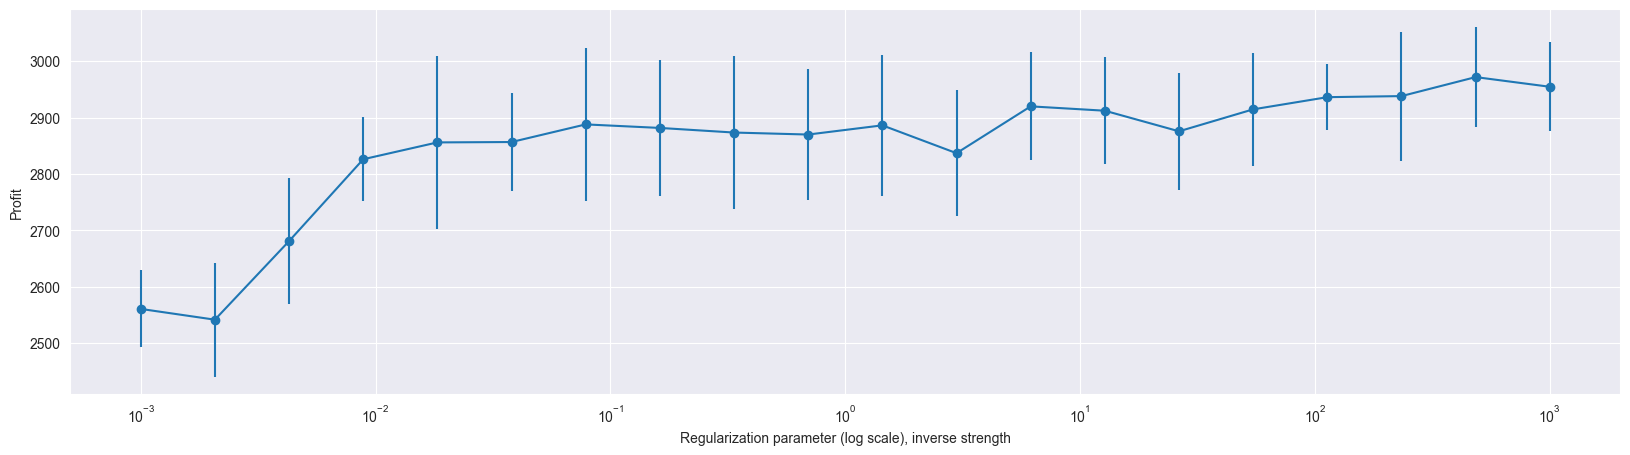

>> maximum profit is reached on: 483.2930238571752


In [36]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(20, 5))
plt.errorbar(x=np.logspace(-3, 3, num=20), y=profit_list_mean_c, yerr=profit_list_std_c, fmt="o-")
plt.xlabel("Regularization parameter (log scale), inverse strength")
plt.ylabel("Profit")
plt.xscale("log")
plt.show()
pprint("maximum profit is reached on:", np.logspace(-3, 3, num=20)[np.argmax(profit_list_mean_c)])

Попробуйте запустить перебор несколько раз. Находится ли каждый раз один и тот же "лучший" коэффициент? Присутствует ли какая-то закономерность? Какие вы можете сделать из этого выводы?

In [38]:
#your code here
# a separate list per regularization
for _ in range(10):
    profit_list_mean_c = []
    profit_list_std_c = []

    for c in np.logspace(-3, 3, num=20):
        revenue_list = []
        costs_list = []
        profit_list = []

        for train_idx, test_idx in KFold(n_splits=5, shuffle=True, random_state=500).split(X):
            X_train, X_test = X.loc[train_idx], X.loc[test_idx]
            y_train, y_test = y.loc[train_idx], y.loc[test_idx]

            column_transformer = ColumnTransformer([
                ("encoder", OneHotEncoder(handle_unknown="error"), categorical_f)
            ], remainder="passthrough")

            log_regression = Pipeline([
                ("column_transformer", column_transformer),
                ("scaler", StandardScaler()),
                ("classifier", LogisticRegression(max_iter=int(1e6), C=c))
            ])
            log_regression.fit(X_train, y_train)
            pred = log_regression.predict(X_test)
            revenue_list.append(np.sum(np.random.uniform(0, 20, size=len(pred)) * pred.astype(int)))
            costs_list.append(1. * np.sum(pred.astype(int)))
            profit_list.append(revenue_list[-1] - costs_list[-1])

        profit_list_mean_c.append(np.mean(profit_list))
        profit_list_std_c.append(np.std(profit_list))

    pprint(f"maximum profit {max(profit_list_mean_c)} is reached on c:", np.logspace(-3, 3, num=20)[np.argmax(profit_list_mean_c)])

>> maximum profit 2994.0889112343248 is reached on c: 2.976351441631316
>> maximum profit 2966.1723336237555 is reached on c: 112.88378916846884
>> maximum profit 2969.103671585694 is reached on c: 2.976351441631316
>> maximum profit 2967.3953438552144 is reached on c: 12.742749857031322
>> maximum profit 3034.7247812424844 is reached on c: 483.2930238571752
>> maximum profit 2976.700769061232 is reached on c: 483.2930238571752
>> maximum profit 3002.8399384887252 is reached on c: 12.742749857031322
>> maximum profit 2974.6871415438845 is reached on c: 233.57214690901213
>> maximum profit 2967.978310155022 is reached on c: 0.07847599703514611
>> maximum profit 3025.5159194009484 is reached on c: 1000.0


__Задание 11 (1.5 балл).__ Выше мы уже описали примерную экономическую модель вашей задачи. Как вы считаете, что для вашего бизнеса важнее — хороший precision или recall модели? Почему?

__Ответ:__



Вспомним, что на самом деле логистическая регрессия предсказывает нам вероятности (`predict_proba(...)`) положительного класса для объекта. Возможно, путем настройки порога бинаризации этих вероятностей мы сможем получить какой-то выигрыш? Проверьте ваши рассуждения выше с помощью настройки порога бинаризации на кросс-валидации для максимизации прибыли. Воспользуйтесь сеткой от 0 до 1 с шагом 0.01. Напомним, что снижение порога дает нам более высокий recall и более низкий precision, и наоборот.

In [ ]:
#your code here

Постройте график зависимости прибыли от порога бинаризации, также отметьте на нем стандартные отклонения. Выделите наилучший порог. 


__Вопрос:__ Замечаете ли вы какую-то закономерность? Для правильного ответа на этот вопрос попробуйте запустить несколько раз и задумайтесь, почему порог получается в какой-то конкретной области?

In [ ]:
#your code here

Каковы значения precision и recall на выбранном пороге? Оцените по кросс-валидации. Также вычислите стандартное отклонение.

In [ ]:
#your code here

__Бонус (0.01 балла):__ что вы кушали в день сдачи данного ДЗ на завтрак?

__Ответ:__